In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data = pd.read_csv('Salary_Data.csv')  # utiliser read_excel pour .xls
import pandas as pd


data

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [14]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [7]:
# Sélectionner les colonnes
X = data[['YearsExperience']].values  # matrice n x 1
y = data['Salary'].values             # vecteur n x 1

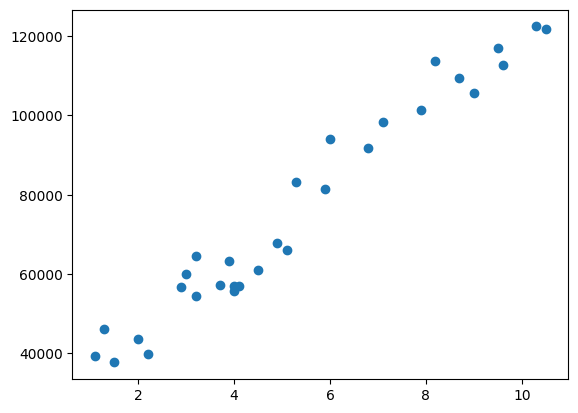

In [8]:
plt.scatter(X,y)

In [10]:
#  Ajouter une colonne de biais (x^0 = 1)
X_b = np.hstack((np.ones((X.shape[0],1)), X))  # n x 2

In [11]:

#  Séparer la base en train et test (manuellement)
# Ici on peut utiliser un découpage simple
np.random.seed(0)
indices = np.arange(X_b.shape[0])
np.random.shuffle(indices)

train_size = int(2/3 * len(indices))
train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = X_b[train_idx]
X_test  = X_b[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]

In [12]:

#  Calculer les coefficients avec la formule normale
# θ = (X^T X)^(-1) X^T y
theta = np.linalg.inv(X_train.T.dot(X_train)).dot(X_train.T).dot(y_train)
intercept = theta[0]
coef = theta[1]

print("Coefficient :", coef)
print("Ordonnée à l'origine :", intercept)

Coefficient : 9399.485728869786
Ordonnée à l'origine : 26204.64277510743


In [25]:
#  Faire les prédictions sur train et test
y_train_pred = X_train.dot(theta)
y_test_pred  = X_test.dot(theta)

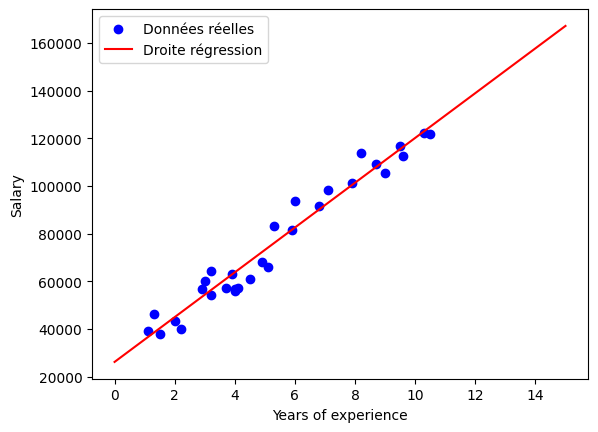

In [26]:
#  Visualiser la droite
ordonner = np.linspace(0, 15, 1000)
plt.scatter(X, y, color='blue', label='Données réelles')
plt.plot(ordonner, coef*ordonner + intercept, color='red', label='Droite régression')
plt.xlabel('Years of experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [27]:
#  Calculer les métriques manuellement
MAE = np.mean(np.abs(y_test - y_test_pred))
MSE = np.mean((y_test - y_test_pred)**2)
RMSE = np.sqrt(MSE)
R2 = 1 - np.sum((y_test - y_test_pred)**2)/np.sum((y_test - np.mean(y_test))**2)

print("MAE :", MAE)
print("MSE :", MSE)
print("RMSE :", RMSE)
print("R² :", R2)

MAE : 4326.605708452074
MSE : 27765848.99183313
RMSE : 5269.330981427635
R² : 0.944342544357082


In [28]:
#  Prédiction sur de nouvelles valeurs
NewData = np.array([[5],[4]])
NewData_b = np.hstack((np.ones((NewData.shape[0],1)), NewData))
y_new = NewData_b.dot(theta)
print("Prédictions pour 5 et 4 années d'expérience :", y_new)

Prédictions pour 5 et 4 années d'expérience : [73202.07141946 63802.58569059]
